In [ ]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


# loading dataset

df = pd.read_csv("Omni_Churn_Data CSV.csv")
print(df.head())

   CustomerID   Age  Gender IncomeTier Region  Education ContractLength  \
0           1  56.0       M        Low   East    Diploma       One year   
1           2  69.0  Female        low  North    Diploma            M2M   
2           3  46.0       M        low  North    Diploma       Two year   
3           4  32.0  Female       HIGH   East    Diploma         3-Year   
4           5  60.0    TRUE  Very High   East  Bachelors       One year   

      PaymentMethod  PlanType  TenureMonths  MonthlyCharges  TotalCharges  \
0  Electronic Check     basic          67.0           87.55     5865.8500   
1            paypal  Standard          97.0          131.96    23765.7428   
2            paypal     Ultra          22.0           79.95     1758.9000   
3  Electronic Check   Premium          65.0          105.84     6879.6000   
4            paypal     Ultra          27.0          134.06     3619.6200   

   LoginsLastMonth  TicketsOpened  TicketsResolutionTime  RFMScore  \
0             21

In [ ]:
# exploring dataset

df.info(verbose=True)
df.describe().T
df.nunique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                50000 non-null  int64  
 1   Age                       49975 non-null  float64
 2   Gender                    50000 non-null  object 
 3   IncomeTier                49800 non-null  object 
 4   Region                    50000 non-null  object 
 5   Education                 49980 non-null  object 
 6   ContractLength            50000 non-null  object 
 7   PaymentMethod             50000 non-null  object 
 8   PlanType                  50000 non-null  object 
 9   TenureMonths              50000 non-null  float64
 10  MonthlyCharges            49990 non-null  float64
 11  TotalCharges              49990 non-null  float64
 12  LoginsLastMonth           50000 non-null  float64
 13  TicketsOpened             50000 non-null  int64  
 14  Ticket

,0
CustomerID,50000
Age,291
Gender,8
IncomeTier,6
Region,5
Education,5
ContractLength,5
PaymentMethod,7
PlanType,7
TenureMonths,284


In [ ]:
# clean Gender column (similar mapping as old notebook)

print(df['Gender'].unique())

df['Gender'] = df['Gender'].replace({
    'TRUE': 'Male',
    'FALSE': 'Female',
    '0': 'Male',
    '1': 'Female',
    'M': 'Male',
    'F': 'Female',
    'm': 'Male',
    'f': 'Female'
})

# strip whitespace and standardize case
df['Gender'] = df['Gender'].astype(str).str.strip().str.title()
print(df['Gender'].unique())

['M' 'Female' 'TRUE' 'Male' '1' '0' 'F' 'FALSE']
['Male' 'Female']


In [ ]:

# clean Gender column (similar mapping as old notebook)

print(df['Gender'].unique())

df['Gender'] = df['Gender'].replace({
    'TRUE': 'Male',
    'FALSE': 'Female',
    '0': 'Male',
    '1': 'Female',
    'M': 'Male',
    'F': 'Female',
    'm': 'Male',
    'f': 'Female'
})

# strip whitespace and standardize case
df['Gender'] = df['Gender'].astype(str).str.strip().str.title()
print(df['Gender'].unique())


['Male' 'Female']
['Male' 'Female']


In [ ]:

# clean Age: handle unrealistic values and missing

print("Age unique (head):", df['Age'].unique()[:20])

# Convert to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Replace ages > 100 with mean of ages <= 100
mean_age = df.loc[df['Age'] <= 100, 'Age'].mean()
print("Mean age for <= 100:", mean_age)

df.loc[df['Age'] > 100, 'Age'] = mean_age

# Fill missing or zero ages with mean_age
df['Age'] = df['Age'].fillna(0)
df.loc[df['Age'] == 0, 'Age'] = mean_age

# Round to whole years
df['Age'] = df['Age'].round()

print("Age unique (after cleaning):", np.sort(df['Age'].unique())[:20])

Age unique (head): [56. 69. 46. 32. 60. 25. 78. 38. 75. 49. 28. 41. 53. 57. 20. 39. 70. 19.
 61. 47.]
Mean age for <= 100: 48.572281767178104
Age unique (after cleaning): [18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37.]


In [ ]:
# standardize IncomeTier

print(df['IncomeTier'].unique())

df['IncomeTier'] = df['IncomeTier'].astype(str).str.lower().str.strip()
df['IncomeTier'] = df['IncomeTier'].fillna('unknown')

print(df['IncomeTier'].unique())


['Low' 'low' 'HIGH' 'Very High' 'High' 'Medium' nan]
['low' 'high' 'very high' 'medium' 'nan']


In [ ]:

# clean Education: fill NaN with 'unknown'

print(df['Education'].unique())

df['Education'] = df['Education'].fillna('unknown')
df['Education'] = df['Education'].astype(str).str.lower().str.strip()

print(df['Education'].unique())

['Diploma' 'Bachelors' 'High School' 'PhD' 'Masters' nan]
['diploma' 'bachelors' 'high school' 'phd' 'masters' 'unknown']


In [ ]:
# standardize ContractLength

print(df['ContractLength'].unique())

df['ContractLength'] = df['ContractLength'].astype(str).str.strip()

df['ContractLength'] = df['ContractLength'].replace({
    'One year': '1 year',
    'Two year': '2 years',
    'M2M': 'Every month',
    'Month-to-month': 'Every month',
    '3-Year': '3 years'
})

print(df['ContractLength'].unique())


['One year' 'M2M' 'Two year' '3-Year' 'Month-to-month']
['1 year' 'Every month' '2 years' '3 years']


In [ ]:

# normalize PlanType

print(df['PlanType'].unique())

df['PlanType'] = df['PlanType'].astype(str).str.lower().str.strip()
df['PlanType'] = df['PlanType'].replace({
    'basik': 'basic'
})

print(df['PlanType'].unique())

['basic' 'Standard' 'Ultra' 'Premium' 'Basic' 'STANDARD' 'Basik']
['basic' 'standard' 'ultra' 'premium']


In [ ]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper


In [ ]:
# TenureMonths outlier handling

lower, upper = iqr_bounds(df['TenureMonths'])
print("TenureMonths bounds:", lower, upper)

print("Count TenureMonths > 180:", (df['TenureMonths'] > 180).sum())


df.loc[df['TenureMonths'] > upper, 'TenureMonths'] = upper

df['TenureMonths'] = df['TenureMonths'].fillna(df['TenureMonths'].median())

df['TenureMonths'].describe()

TenureMonths bounds: -60.0 180.0
Count TenureMonths > 180: 150


,TenureMonths
count,50000.000000
mean,59.943780
std,35.272716
min,0.000000
25%,30.000000
50%,60.000000
75%,90.000000
max,180.000000


In [ ]:
# MonthlyCharges outlier handling

MonthlyCharges_lower, MonthlyCharges_upper = iqr_bounds(df['MonthlyCharges'])
print("MonthlyCharges bounds:", MonthlyCharges_lower, MonthlyCharges_upper)

print("Count MonthlyCharges above upper:", (df['MonthlyCharges'] > MonthlyCharges_upper).sum())


df.loc[df['MonthlyCharges'] > MonthlyCharges_upper, 'MonthlyCharges'] = MonthlyCharges_upper

# Fill missing values with 0 then replace zeros with median
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(0)
median_mcharges = df['MonthlyCharges'].median()
print("Median MonthlyCharges:", median_mcharges)

df.loc[df['MonthlyCharges'] == 0, 'MonthlyCharges'] = median_mcharges

df['MonthlyCharges'].describe()

MonthlyCharges bounds: -65.56 276.18
Count MonthlyCharges above upper: 150
Median MonthlyCharges: 105.165


,MonthlyCharges
count,50000.000000
mean,105.466884
std,53.000699
min,10.000000
25%,62.600000
50%,105.165000
75%,148.020000
max,276.180000


In [ ]:
# TotalCharges outlier handling

TotalCharges_lower, TotalCharges_upper = iqr_bounds(df['TotalCharges'])
print("TotalCharges bounds:", TotalCharges_lower, TotalCharges_upper)


df.loc[df['TotalCharges'] > TotalCharges_upper, 'TotalCharges'] = TotalCharges_upper

# If any negative values, flip to positive
df.loc[df['TotalCharges'] < 0, 'TotalCharges'] = -df.loc[df['TotalCharges'] < 0, 'TotalCharges']

# Fill missing values with 0 then replace zeros with median
df['TotalCharges'] = df['TotalCharges'].fillna(0)

median_Tcharges = df['TotalCharges'].median()
print("Median TotalCharges:", median_Tcharges)

df.loc[df['TotalCharges'] == 0, 'TotalCharges'] = median_Tcharges

df['TotalCharges'].describe()

TotalCharges bounds: -7838.8687500000015 19081.901250000003
Median TotalCharges: 4913.795


,TotalCharges
count,50000.000000
mean,6258.074563
std,4995.184497
min,10.260000
25%,2327.127500
50%,4913.795000
75%,8984.660000
max,19081.901250


In [ ]:

# LoginsLastMonth outlier handling

Logins_lower, Logins_upper = iqr_bounds(df['LoginsLastMonth'])
print("LoginsLastMonth bounds:", Logins_lower, Logins_upper)


df.loc[df['LoginsLastMonth'] > Logins_upper, 'LoginsLastMonth'] = Logins_upper

print("Count LoginsLastMonth > 151.5 (original threshold):",
      (df['LoginsLastMonth'] > 151.5).sum())

df['LoginsLastMonth'].describe()

LoginsLastMonth bounds: -52.5 151.5
Count LoginsLastMonth > 151.5 (original threshold): 0


,LoginsLastMonth
count,50000.00000
mean,49.60300
std,29.38413
min,0.00000
25%,24.00000
50%,49.00000
75%,75.00000
max,151.50000


In [ ]:

# TicketsResolutionTime outlier handling

TRT_lower, TRT_upper = iqr_bounds(df['TicketsResolutionTime'])
print("TicketsResolutionTime bounds:", TRT_lower, TRT_upper)

print("Count TicketsResolutionTime > upper bound:",
      (df['TicketsResolutionTime'] > TRT_upper).sum())


df.loc[df['TicketsResolutionTime'] > TRT_upper, 'TicketsResolutionTime'] = TRT_upper

df['TicketsResolutionTime'].describe()

TicketsResolutionTime bounds: -35.23823741124999 107.95477351874999
Count TicketsResolutionTime > upper bound: 120


,TicketsResolutionTime
count,50000.000000
mean,36.476656
std,20.894714
min,0.500239
25%,18.459142
50%,36.484162
75%,54.257394
max,107.954774


In [ ]:
# fill and standardize multiple categorical columns

rem_columns = [
    'DeviceType', 'ChannelPreferred', 'AutoPay', 'Paperless', 'FamilyPlan',
    'AddOnBundle', 'ComplaintCategory', 'DiscountType', 'ContractAutoRenew',
    'DeviceOS', 'PromoCodeUsed', 'CustomerSegment', 'ReferralSource',
    'SupportChannelPreferred', 'CityTier', 'PaymentDelinquencyStatus'
]

for col in rem_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()
        df[col] = df[col].replace({'nan': 'unknown', 'none': 'unknown', '': 'unknown'})
        df[col] = df[col].fillna('unknown')

# Check one example
print(df['FamilyPlan'].unique())

['no' 'yes' 'unknown']


In [ ]:
print("Before Cleaning - FamilyPlan unique values:")
print(df['FamilyPlan'].unique())

# Columns requiring lowercasing, trimming and binary mapping
rem_columns = [
    'DeviceType', 'ChannelPreferred', 'AutoPay', 'Paperless', 'FamilyPlan',
    'AddOnBundle', 'ComplaintCategory', 'DiscountType',
    'ContractAutoRenew', 'DeviceOS', 'PromoCodeUsed'
]

# Ensure all columns exist before cleaning
rem_columns = [col for col in rem_columns if col in df.columns]


# Step 1: Replace missing values with 'unknown'
df[rem_columns] = df[rem_columns].fillna('unknown')


# Step 2: Standardise formatting

for col in rem_columns:
    df[col] = df[col].astype(str).str.lower().str.strip()


# Step 3: Binary mapping

binary_map = {
    'true': 'yes',
    '0': 'yes',
    'y': 'yes',
    'yes': 'yes',
    'false': 'no',
    '1': 'no',
    'n': 'no',
    'no': 'no'
}

df[['AutoPay','Paperless','FamilyPlan','ContractAutoRenew','PromoCodeUsed']] = \
    df[['AutoPay','Paperless','FamilyPlan','ContractAutoRenew','PromoCodeUsed']].replace(binary_map)


# Step 4: DeviceType corrections

df['DeviceType'] = df['DeviceType'].replace({
    'm0bile': 'mobile',
    '??': 'unknown',
    '???': 'unknown',
    'none': 'unknown'
})

# Step 5: Handle blank strings explicitly

df['FamilyPlan'] = df['FamilyPlan'].replace('', 'unknown')


# Final check before saving cleaned file

print("\nAfter Cleaning - FamilyPlan unique values:")
print(df['FamilyPlan'].unique())

print("\nCleaning Completed. Ready to save the new cleaned dataset.")
df.describe().T

Before Cleaning - FamilyPlan unique values:
['no' 'yes' 'unknown']

After Cleaning - FamilyPlan unique values:
['no' 'yes' 'unknown']

Cleaning Completed. Ready to save the new cleaned dataset.


,count,mean,std,min,25%,50%,75%,max
CustomerID,50000.0,25000.500000,14433.901067,1.000000,12500.750000,25000.500000,37500.250000,50000.000000
Age,50000.0,48.574600,16.929905,18.000000,35.000000,49.000000,62.000000,79.000000
TenureMonths,50000.0,59.943780,35.272716,0.000000,30.000000,60.000000,90.000000,180.000000
MonthlyCharges,50000.0,105.466884,53.000699,10.000000,62.600000,105.165000,148.020000,276.180000
TotalCharges,50000.0,6258.074563,4995.184497,10.260000,2327.127500,4913.795000,8984.660000,19081.901250
LoginsLastMonth,50000.0,49.603000,29.384130,0.000000,24.000000,49.000000,75.000000,151.500000
TicketsOpened,50000.0,9.479920,5.767504,0.000000,4.000000,9.000000,14.000000,19.000000
TicketsResolutionTime,50000.0,36.476656,20.894714,0.500239,18.459142,36.484162,54.257394,107.954774
RFMScore,50000.0,7.530080,4.035902,1.000000,4.000000,8.000000,11.000000,14.000000
UsageChangePct,50000.0,0.007362,0.600499,-8.473823,-0.495843,0.002292,0.505086,9.605616


In [ ]:
print(df.head())
df.info(verbose=True)
df.nunique()
df.describe().T


   CustomerID   Age  Gender IncomeTier Region  Education ContractLength  \
0           1  56.0    Male        low   East    diploma         1 year   
1           2  69.0  Female        low  North    diploma    Every month   
2           3  46.0    Male        low  North    diploma        2 years   
3           4  32.0  Female       high   East    diploma        3 years   
4           5  60.0    Male  very high   East  bachelors         1 year   

      PaymentMethod  PlanType  TenureMonths  MonthlyCharges  TotalCharges  \
0  Electronic Check     basic          67.0           87.55    5865.85000   
1            paypal  standard          97.0          131.96   19081.90125   
2            paypal     ultra          22.0           79.95    1758.90000   
3  Electronic Check   premium          65.0          105.84    6879.60000   
4            paypal     ultra          27.0          134.06    3619.62000   

   LoginsLastMonth  TicketsOpened  TicketsResolutionTime  RFMScore  \
0             21

,count,mean,std,min,25%,50%,75%,max
CustomerID,50000.0,25000.500000,14433.901067,1.000000,12500.750000,25000.500000,37500.250000,50000.000000
Age,50000.0,48.574600,16.929905,18.000000,35.000000,49.000000,62.000000,79.000000
TenureMonths,50000.0,59.943780,35.272716,0.000000,30.000000,60.000000,90.000000,180.000000
MonthlyCharges,50000.0,105.466884,53.000699,10.000000,62.600000,105.165000,148.020000,276.180000
TotalCharges,50000.0,6258.074563,4995.184497,10.260000,2327.127500,4913.795000,8984.660000,19081.901250
LoginsLastMonth,50000.0,49.603000,29.384130,0.000000,24.000000,49.000000,75.000000,151.500000
TicketsOpened,50000.0,9.479920,5.767504,0.000000,4.000000,9.000000,14.000000,19.000000
TicketsResolutionTime,50000.0,36.476656,20.894714,0.500239,18.459142,36.484162,54.257394,107.954774
RFMScore,50000.0,7.530080,4.035902,1.000000,4.000000,8.000000,11.000000,14.000000
UsageChangePct,50000.0,0.007362,0.600499,-8.473823,-0.495843,0.002292,0.505086,9.605616


In [ ]:
df.to_csv("cleaned_omni_churn_data.csv", index=False)

cleaned = pd.read_csv("cleaned_omni_churn_data.csv")
print(cleaned.head())

   CustomerID   Age  Gender IncomeTier Region  Education ContractLength  \
0           1  56.0    Male        low   East    diploma         1 year   
1           2  69.0  Female        low  North    diploma    Every month   
2           3  46.0    Male        low  North    diploma        2 years   
3           4  32.0  Female       high   East    diploma        3 years   
4           5  60.0    Male  very high   East  bachelors         1 year   

      PaymentMethod  PlanType  TenureMonths  MonthlyCharges  TotalCharges  \
0  Electronic Check     basic          67.0           87.55    5865.85000   
1            paypal  standard          97.0          131.96   19081.90125   
2            paypal     ultra          22.0           79.95    1758.90000   
3  Electronic Check   premium          65.0          105.84    6879.60000   
4            paypal     ultra          27.0          134.06    3619.62000   

   LoginsLastMonth  TicketsOpened  TicketsResolutionTime  RFMScore  \
0             21

In [ ]:
!pip install shap lime xgboost


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3b7ea17262af1b86367db6f03a0c68c331d8a10649351ad46a59bc6b3bb53759
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
import pandas as pd

# 1. Load data (use your exact uploaded filename)
df = pd.read_csv("cleaned_omni_churn_data (1).csv")

# 2. Separate target and drop ID column
y = df["Churn"]
X = df.drop(columns=["Churn", "CustomerID"])


In [ ]:
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Define numeric / categorical columns (adjust if needed)
numeric_features = [
    "Age", "TenureMonths", "MonthlyCharges", "TotalCharges",
    "LoginsLastMonth", "TicketsOpened", "TicketsResolutionTime",
    "RFMScore", "UsageChangePct", "CompetitorIndex"
]

categorical_features = [
    "Gender","IncomeTier","Region","Education","ContractLength",
    "PaymentMethod","PlanType","DeviceType","ChannelPreferred",
    "CustomerSegment","AutoPay","Paperless","FamilyPlan","AddOnBundle",
    "ReferralSource","SupportChannelPreferred","ComplaintCategory",
    "DiscountType","ContractAutoRenew","DeviceOS","CityTier",
    "PromoCodeUsed","PaymentDelinquencyStatus"
]

# 2. Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Fit preprocessor and create encoded matrices
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

# 5. CV strategy (3-fold for speed)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 6. Smaller subset for hyperparameter tuning (50% of training set)
X_tune, _, y_tune, _ = train_test_split(
    X_train_enc, y_train, train_size=0.5,
    stratify=y_train, random_state=42
)


In [ ]:
from collections import OrderedDict
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
)

def evaluate_model(name, model, X_train_enc, y_train, X_test_enc, y_test, results_dict):
    model.fit(X_train_enc, y_train)
    y_prob = model.predict_proba(X_test_enc)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "model": model
    }
    results_dict[name] = metrics
    print(f"\n{name}")
    print("ROC-AUC :", metrics["ROC_AUC"])
    print("Accuracy:", metrics["Accuracy"])
    print("Precision:", metrics["Precision"])
    print("Recall:", metrics["Recall"])
    print("F1:", metrics["F1"])
    return model

results = OrderedDict()


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs"
)

log_reg_param_dist = {
    "C": np.logspace(-1, 1, 5)
}

log_reg_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=log_reg_param_dist,
    n_iter=5,
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

log_reg_search.fit(X_tune, y_tune)
print("Logistic Regression best params:", log_reg_search.best_params_)

log_reg_best = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs",
    **log_reg_search.best_params_
)

log_reg_best = evaluate_model(
    "Logistic Regression", log_reg_best,
    X_train_enc, y_train, X_test_enc, y_test, results
)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Logistic Regression best params: {'C': np.float64(0.1)}

Logistic Regression
ROC-AUC : 0.7349107068607068
Accuracy: 0.7028
Precision: 0.4486187845303867
Recall: 0.6246153846153846
F1: 0.5221864951768489


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)

dt_param_dist = {
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 10, 50],
    "min_samples_leaf": [1, 5, 20]
}

dt_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=dt_param_dist,
    n_iter=10,
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

dt_search.fit(X_tune, y_tune)
print("Decision Tree best params:", dt_search.best_params_)

dt_best = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    **dt_search.best_params_
)

dt_best = evaluate_model(
    "Decision Tree", dt_best,
    X_train_enc, y_train, X_test_enc, y_test, results
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Decision Tree best params: {'min_samples_split': 10, 'min_samples_leaf': 20, 'max_depth': 5}

Decision Tree
ROC-AUC : 0.7054753118503118
Accuracy: 0.7634
Precision: 0.5520926090828139
Recall: 0.47692307692307695
F1: 0.5117622781675609


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Faster Random Forest: fewer trees, tiny search space, fewer iterations
rf = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_param_dist = {
    "n_estimators": [60, 100],       # fewer trees
    "max_depth": [None, 8, 12],      # small set of depths
    "min_samples_leaf": [1, 2],      # only two options
    "max_features": ["sqrt", 0.5]    # limited options
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=4,               # much smaller than before
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

# still tuning on the reduced X_tune for speed
rf_search.fit(X_tune, y_tune)
print("Random Forest (FAST) best params:", rf_search.best_params_)

rf_best = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    **rf_search.best_params_
)

rf_best = evaluate_model(
    "Random Forest", rf_best,
    X_train_enc, y_train, X_test_enc, y_test, results
)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Random Forest (FAST) best params: {'n_estimators': 60, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 12}

Random Forest
ROC-AUC : 0.7290524948024948
Accuracy: 0.8027
Precision: 0.6663129973474801
Recall: 0.48307692307692307
F1: 0.5600891861761427


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Faster Gradient Boosting: smaller search + n_estimators
gb = GradientBoostingClassifier(random_state=42)

gb_param_dist = {
    "n_estimators": [80, 120],     # fewer boosting stages
    "learning_rate": [0.05, 0.1],  # small range
    "max_depth": [3, 4]            # shallow trees
}

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_dist,
    n_iter=4,             # reduced iterations
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

gb_search.fit(X_tune, y_tune)
print("Gradient Boosting (FAST) best params:", gb_search.best_params_)

gb_best = GradientBoostingClassifier(
    random_state=42,
    **gb_search.best_params_
)

gb_best = evaluate_model(
    "Gradient Boosting", gb_best,
    X_train_enc, y_train, X_test_enc, y_test, results
)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Gradient Boosting (FAST) best params: {'n_estimators': 120, 'max_depth': 4, 'learning_rate': 0.1}

Gradient Boosting
ROC-AUC : 0.7372904885654886
Accuracy: 0.8301
Precision: 0.8618473895582329
Recall: 0.4126923076923077
F1: 0.5581274382314695


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

xgb_param_dist = {
    "n_estimators": [150, 250],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_tune, y_tune)
print("XGBoost best params:", xgb_search.best_params_)

xgb_best = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
    **xgb_search.best_params_
)

xgb_best = evaluate_model(
    "XGBoost", xgb_best,
    X_train_enc, y_train, X_test_enc, y_test, results
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:17:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost best params: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

XGBoost
ROC-AUC : 0.7352512214137215
Accuracy: 0.8322
Precision: 0.862992125984252
Recall: 0.42153846153846153
F1: 0.5664082687338501


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

lin_svm = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

lin_svm_param_dist = {
    "C": [0.01, 0.1, 1, 5, 10]
}

lin_svm_search = RandomizedSearchCV(
    estimator=lin_svm,
    param_distributions=lin_svm_param_dist,
    n_iter=5,
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

lin_svm_search.fit(X_tune, y_tune)
print("Linear SVM best params:", lin_svm_search.best_params_)

lin_svm_best = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
    **lin_svm_search.best_params_
)

lin_svm_calibrated = CalibratedClassifierCV(
    lin_svm_best, method="sigmoid", cv=3
)

lin_svm_final = evaluate_model(
    "SVM (Linear + Calibrated)", lin_svm_calibrated,
    X_train_enc, y_train, X_test_enc, y_test, results
)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Linear SVM best params: {'C': 0.01}

SVM (Linear + Calibrated)
ROC-AUC : 0.736047765072765
Accuracy: 0.8227
Precision: 0.8454469507101086
Recall: 0.3892307692307692
F1: 0.5330524097972084


In [ ]:
from sklearn.neural_network import MLPClassifier
from scipy import sparse

# Dense copies for MLP
X_train_mlp = X_train_enc.toarray() if sparse.issparse(X_train_enc) else X_train_enc
X_test_mlp  = X_test_enc.toarray()  if sparse.issparse(X_test_enc)  else X_test_enc
X_tune_mlp  = X_tune.toarray()      if sparse.issparse(X_tune)      else X_tune

mlp = MLPClassifier(
    max_iter=200,
    early_stopping=True,
    random_state=42
)

mlp_param_dist = {
    "hidden_layer_sizes": [(64,), (64, 32), (128,)],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [0.001, 0.01]
}

mlp_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=mlp_param_dist,
    n_iter=10,
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

mlp_search.fit(X_tune_mlp, y_tune)
print("MLP best params:", mlp_search.best_params_)

mlp_best = MLPClassifier(
    max_iter=200,
    early_stopping=True,
    random_state=42,
    **mlp_search.best_params_
)

mlp_best = evaluate_model(
    "ANN / MLP", mlp_best,
    X_train_mlp, y_train, X_test_mlp, y_test, results
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
MLP best params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'alpha': 0.0001}

ANN / MLP
ROC-AUC : 0.7361472453222453
Accuracy: 0.8362
Precision: 0.8649468892261002
Recall: 0.43846153846153846
F1: 0.5819295558958653


In [ ]:
summary = pd.DataFrame({
    model: {metric: val for metric, val in res.items() if metric != "model"}
    for model, res in results.items()
}).T

summary


,ROC_AUC,Accuracy,Precision,Recall,F1
Logistic Regression,0.734911,0.7028,0.448619,0.624615,0.522186
Decision Tree,0.705475,0.7634,0.552093,0.476923,0.511762
Random Forest,0.729052,0.8027,0.666313,0.483077,0.560089
Gradient Boosting,0.737290,0.8301,0.861847,0.412692,0.558127
XGBoost,0.735251,0.8322,0.862992,0.421538,0.566408
SVM (Linear + Calibrated),0.736048,0.8227,0.845447,0.389231,0.533052
ANN / MLP,0.736147,0.8362,0.864947,0.438462,0.581930


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = {}

for name, res in results.items():
    print("\n" + "="*70)
    print(f"Cross-validation for: {name}")
    model = res["model"]

    if name == "ANN / MLP":
        X_cv = X_train_mlp
    else:
        X_cv = X_train_enc

    scores = cross_val_score(
        model,
        X_cv,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_scores[name] = {
        "cv_mean_auc": scores.mean(),
        "cv_std_auc": scores.std()
    }

    print(f"ROC-AUC CV mean: {scores.mean():.4f}  |  std: {scores.std():.4f}")



Cross-validation for: Logistic Regression
ROC-AUC CV mean: 0.7291  |  std: 0.0043

Cross-validation for: Decision Tree
ROC-AUC CV mean: 0.7028  |  std: 0.0027

Cross-validation for: Random Forest
ROC-AUC CV mean: 0.7231  |  std: 0.0057

Cross-validation for: Gradient Boosting
ROC-AUC CV mean: 0.7333  |  std: 0.0055

Cross-validation for: XGBoost
ROC-AUC CV mean: 0.7324  |  std: 0.0055

Cross-validation for: SVM (Linear + Calibrated)
ROC-AUC CV mean: 0.7299  |  std: 0.0045

Cross-validation for: ANN / MLP
ROC-AUC CV mean: 0.7361  |  std: 0.0038


In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 20.5 MB/s eta 0:00:00


In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 220),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        use_label_encoder=False,
        n_jobs=-1,
        random_state=42,
        **params
    )

    scores = cross_val_score(
        model,
        X_train_enc,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)

print("Best Optuna params:", study.best_params)
print("Best CV ROC-AUC:", study.best_value)

xgb_optuna_best = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
    **study.best_params
)

xgb_optuna_best = evaluate_model(
    "XGBoost (Optuna)", xgb_optuna_best,
    X_train_enc, y_train, X_test_enc, y_test, results
)


[I 2025-12-05 19:31:07,166] A new study created in memory with name: no-name-1b564848-d784-45e4-80b9-9f65176d8e9e


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-12-05 19:31:12,974] Trial 0 finished with value: 0.7336084558006766 and parameters: {'n_estimators': 126, 'max_depth': 5, 'learning_rate': 0.12992579155657125, 'subsample': 0.6730082035513442, 'colsample_bytree': 0.683446080345814, 'min_child_weight': 4, 'reg_lambda': 0.002559545730450731}. Best is trial 0 with value: 0.7336084558006766.
[I 2025-12-05 19:31:18,197] Trial 1 finished with value: 0.7321626498632972 and parameters: {'n_estimators': 154, 'max_depth': 5, 'learning_rate': 0.038681025675921, 'subsample': 0.806704191515285, 'colsample_bytree': 0.7179353286926652, 'min_child_weight': 3, 'reg_lambda': 0.02917149175882168}. Best is trial 0 with value: 0.7336084558006766.
[I 2025-12-05 19:31:23,950] Trial 2 finished with value: 0.7345032894276408 and parameters: {'n_estimators': 141, 'max_depth': 4, 'learning_rate': 0.13711959530679285, 'subsample': 0.7053266531824038, 'colsample_bytree': 0.6778026829317729, 'min_child_weight': 5, 'reg_lambda': 0.0014965191184358926}. Best 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:32:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (Optuna)
ROC-AUC : 0.7344319646569646
Accuracy: 0.8333
Precision: 0.8624708624708625
Recall: 0.4269230769230769
F1: 0.5711345510676614



Model: Logistic Regression
Confusion matrix (rows=true, cols=pred):
[[5404 1996]
 [ 976 1624]]


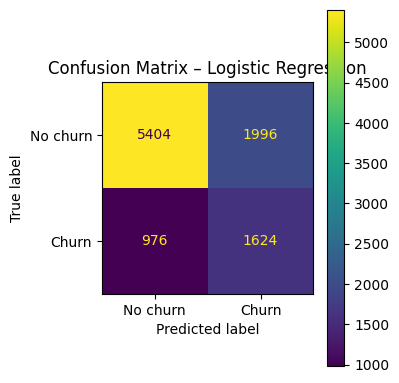


Classification report:
              precision    recall  f1-score   support

    No churn       0.85      0.73      0.78      7400
       Churn       0.45      0.62      0.52      2600

    accuracy                           0.70     10000
   macro avg       0.65      0.68      0.65     10000
weighted avg       0.74      0.70      0.72     10000


Model: Decision Tree
Confusion matrix (rows=true, cols=pred):
[[6394 1006]
 [1360 1240]]


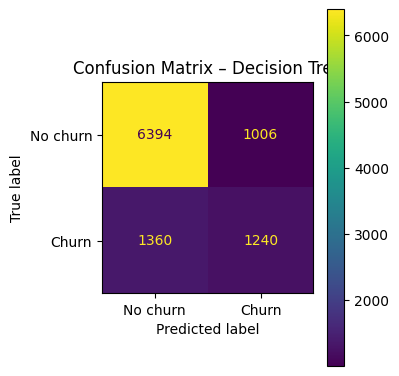


Classification report:
              precision    recall  f1-score   support

    No churn       0.82      0.86      0.84      7400
       Churn       0.55      0.48      0.51      2600

    accuracy                           0.76     10000
   macro avg       0.69      0.67      0.68     10000
weighted avg       0.75      0.76      0.76     10000


Model: Random Forest
Confusion matrix (rows=true, cols=pred):
[[6771  629]
 [1344 1256]]


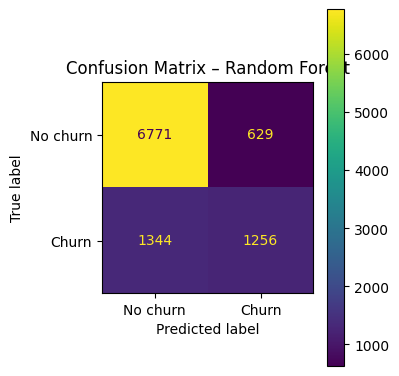


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.92      0.87      7400
       Churn       0.67      0.48      0.56      2600

    accuracy                           0.80     10000
   macro avg       0.75      0.70      0.72     10000
weighted avg       0.79      0.80      0.79     10000


Model: Gradient Boosting
Confusion matrix (rows=true, cols=pred):
[[7228  172]
 [1527 1073]]


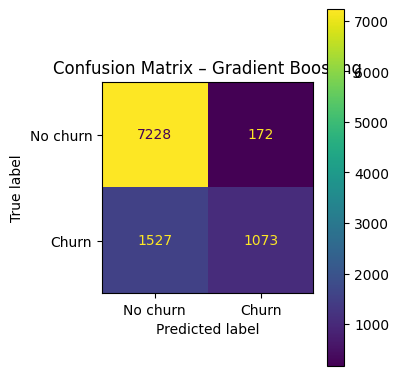


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.98      0.89      7400
       Churn       0.86      0.41      0.56      2600

    accuracy                           0.83     10000
   macro avg       0.84      0.69      0.73     10000
weighted avg       0.84      0.83      0.81     10000


Model: XGBoost
Confusion matrix (rows=true, cols=pred):
[[7226  174]
 [1504 1096]]


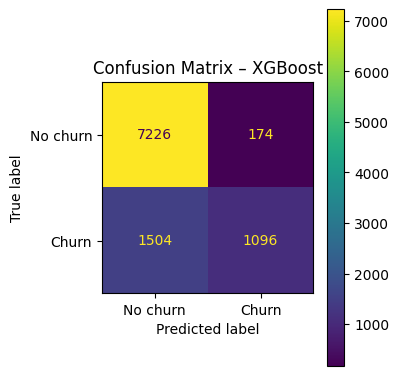


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.98      0.90      7400
       Churn       0.86      0.42      0.57      2600

    accuracy                           0.83     10000
   macro avg       0.85      0.70      0.73     10000
weighted avg       0.84      0.83      0.81     10000


Model: SVM (Linear + Calibrated)
Confusion matrix (rows=true, cols=pred):
[[7215  185]
 [1588 1012]]


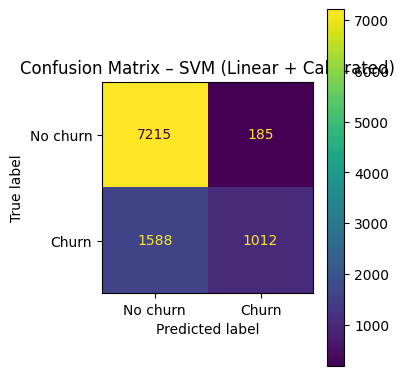


Classification report:
              precision    recall  f1-score   support

    No churn       0.82      0.97      0.89      7400
       Churn       0.85      0.39      0.53      2600

    accuracy                           0.82     10000
   macro avg       0.83      0.68      0.71     10000
weighted avg       0.83      0.82      0.80     10000


Model: ANN / MLP
Confusion matrix (rows=true, cols=pred):
[[7222  178]
 [1460 1140]]


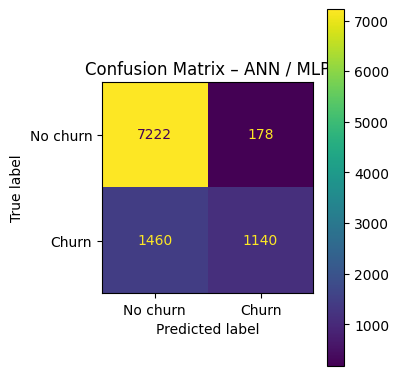


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.98      0.90      7400
       Churn       0.86      0.44      0.58      2600

    accuracy                           0.84     10000
   macro avg       0.85      0.71      0.74     10000
weighted avg       0.84      0.84      0.82     10000


Model: XGBoost (Optuna)
Confusion matrix (rows=true, cols=pred):
[[7223  177]
 [1490 1110]]


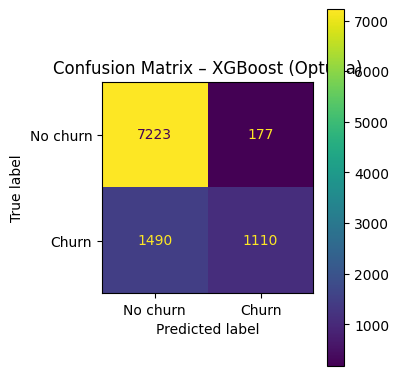


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.98      0.90      7400
       Churn       0.86      0.43      0.57      2600

    accuracy                           0.83     10000
   macro avg       0.85      0.70      0.73     10000
weighted avg       0.84      0.83      0.81     10000



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

THRESHOLD = 0.5

for name, res in results.items():
    print("\n" + "="*70)
    print(f"Model: {name}")
    model = res["model"]

    if name == "ANN / MLP":
        X_eval = X_test_mlp
    else:
        X_eval = X_test_enc

    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion Matrix – {name}")
    plt.tight_layout()
    plt.show()

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))


In [ ]:
import numpy as np

champ_name = max(results.keys(), key=lambda m: results[m]["ROC_AUC"])
champ_model = results[champ_name]["model"]
print(f"Champion model (highest ROC_AUC): {champ_name}")

if champ_name == "ANN / MLP":
    X_eval = X_test_mlp
else:
    X_eval = X_test_enc

y_prob_champ = champ_model.predict_proba(X_eval)[:, 1]
y_pred_champ = (y_prob_champ >= 0.5).astype(int)

error_df = X_test.copy()
error_df["Churn_true"] = y_test.values
error_df["Churn_pred"] = y_pred_champ
error_df["Churn_prob"] = y_prob_champ

conds = [
    (error_df["Churn_true"] == 1) & (error_df["Churn_pred"] == 1),
    (error_df["Churn_true"] == 0) & (error_df["Churn_pred"] == 0),
    (error_df["Churn_true"] == 0) & (error_df["Churn_pred"] == 1),
    (error_df["Churn_true"] == 1) & (error_df["Churn_pred"] == 0),
]
labels = ["TP", "TN", "FP", "FN"]

error_df["error_type"] = np.select(conds, labels, default="Other")

print("\nCounts by error type:")
print(error_df["error_type"].value_counts())

fn_df = error_df[error_df["error_type"] == "FN"]
print("\nSample of missed churners (FN):")
display(fn_df.head(10))

group_cols = ["ContractLength", "CustomerSegment", "PaymentDelinquencyStatus"]

for col in group_cols:
    if col in error_df.columns:
        print(f"\nError breakdown by {col}:")
        summary_err = (
            error_df
            .groupby(col)["error_type"]
            .value_counts()
            .unstack(fill_value=0)
        )
        display(summary_err)
    else:
        print(f"\n[Info] Column '{col}' not in X_test, skipping.")


Champion model (highest ROC_AUC): Gradient Boosting

Counts by error type:
error_type
TN    7228
FN    1527
TP    1073
FP     172
Name: count, dtype: int64

Sample of missed churners (FN):


,Age,Gender,IncomeTier,Region,Education,ContractLength,PaymentMethod,PlanType,TenureMonths,MonthlyCharges,...,DiscountType,ContractAutoRenew,DeviceOS,CityTier,PromoCodeUsed,PaymentDelinquencyStatus,Churn_true,Churn_pred,Churn_prob,error_type
5636,54.0,Female,low,West,diploma,Every month,Bank Transfer,basic,47.0,156.84,...,intro,no,linux,tier-3,summer,current,1,0,0.303549,FN
5363,44.0,Male,low,North,diploma,Every month,cash,premium,10.0,161.70,...,loyalty,yes,android,tier-1,summer,current,1,0,0.230583,FN
21601,51.0,Female,medium,East,masters,2 years,Crypto,basic,98.0,47.41,...,loyalty,no,android,tier-3,flash,current,1,0,0.128268,FN
43871,56.0,Male,low,South,diploma,Every month,paypal,basic,44.0,13.52,...,intro,no,android,tier-1,summer,current,1,0,0.239245,FN
37112,50.0,Male,low,Central,diploma,Every month,Bank Transfer,standard,51.0,143.11,...,loyalty,yes,android,tier-2,cyber,current,1,0,0.189279,FN
49523,44.0,Male,low,South,phd,3 years,Electronic Check,standard,15.0,153.60,...,student,no,android,tier-2,summer,current,1,0,0.121118,FN
5471,59.0,Male,high,Central,diploma,3 years,cash,basic,1.0,120.28,...,loyalty,no,windows,tier-1,newyear,current,1,0,0.310924,FN
49679,50.0,Female,high,South,high school,Every month,Credit Card,basic,58.0,104.60,...,loyalty,no,ios,tier-1,summer,current,1,0,0.366376,FN
41625,59.0,Male,high,Central,diploma,3 years,paypal,basic,44.0,173.60,...,intro,yes,linux,tier-2,summer,current,1,0,0.189687,FN
12853,69.0,Female,low,Central,high school,1 year,Electronic Check,basic,31.0,82.70,...,loyalty,no,ios,tier-1,summer,current,1,0,0.348723,FN



Error breakdown by ContractLength:


error_type,FN,FP,TN,TP
ContractLength,,,,
1 year,328,33,1482,150
2 years,298,35,1499,147
3 years,291,36,1498,171
Every month,610,68,2749,605



Error breakdown by CustomerSegment:


error_type,FN,FP,TN,TP
CustomerSegment,,,,
bronze,531,68,2454,381
diamond,66,11,368,57
gold,298,39,1441,206
platinum,170,13,743,115
silver,462,41,2222,314



Error breakdown by PaymentDelinquencyStatus:


error_type,FN,FP,TN,TP
PaymentDelinquencyStatus,,,,
120+,7,16,10,85
30+,116,49,596,262
60+,65,42,219,229
90+,24,25,76,177
current,1315,40,6327,320


Top 20 RF feature importances:
cat__PaymentDelinquencyStatus_current    0.114924
num__TenureMonths                        0.102471
num__CompetitorIndex                     0.062974
num__MonthlyCharges                      0.053211
num__UsageChangePct                      0.047204
cat__ContractAutoRenew_yes               0.046073
num__TicketsOpened                       0.042989
cat__PaymentDelinquencyStatus_90+        0.038731
num__TicketsResolutionTime               0.038196
num__TotalCharges                        0.036881
cat__PaymentDelinquencyStatus_60+        0.028249
cat__ContractAutoRenew_no                0.022938
num__LoginsLastMonth                     0.022789
num__Age                                 0.019920
cat__PaymentDelinquencyStatus_120+       0.019775
cat__PaymentDelinquencyStatus_30+        0.015592
num__RFMScore                            0.014601
cat__ContractLength_Every month          0.011279
cat__AutoPay_no                          0.007256
cat__AutoPay_yes   

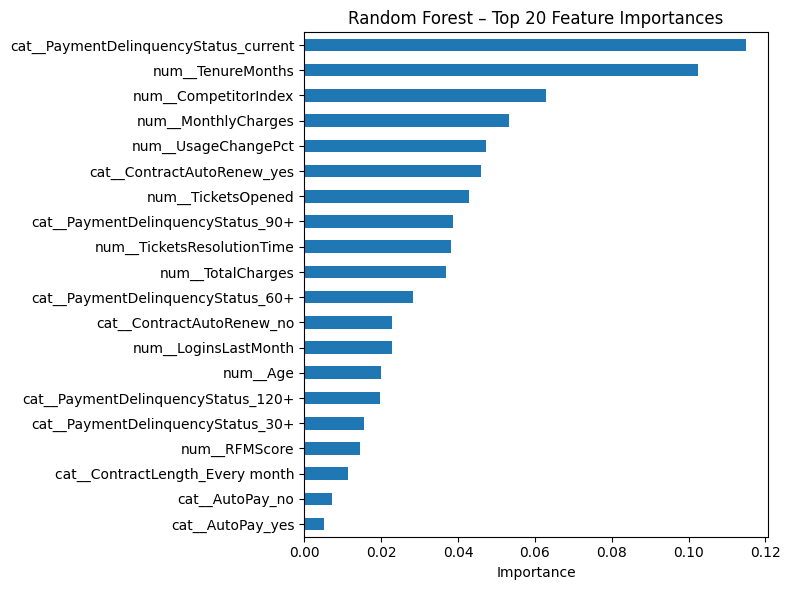

In [ ]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(
    rf_best.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top 20 RF feature importances:")
print(rf_importances.head(20))

top20 = rf_importances.head(20)
plt.figure(figsize=(8, 6))
top20[::-1].plot(kind="barh")
plt.title("Random Forest – Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


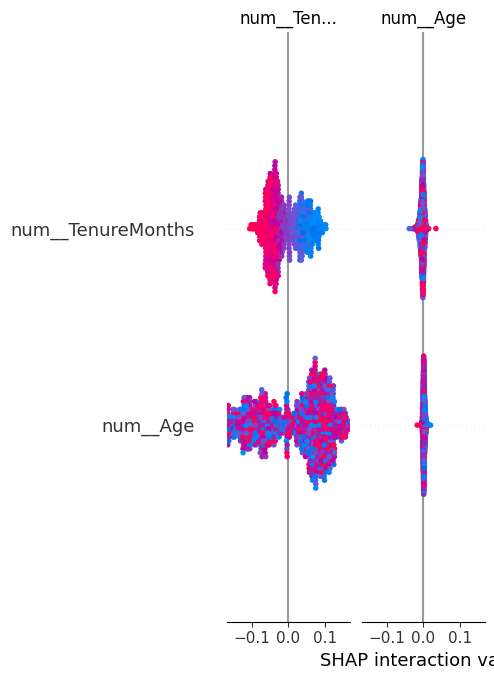

In [ ]:
import shap
import scipy.sparse as sp

X_train_for_shap = X_train_enc
X_test_for_shap = X_test_enc

if sp.issparse(X_train_for_shap):
    X_train_for_shap = X_train_for_shap.toarray()
if sp.issparse(X_test_for_shap):
    X_test_for_shap = X_test_for_shap.toarray()

X_train_for_shap = X_train_for_shap.astype(float)
X_test_for_shap = X_test_for_shap.astype(float)

n_background = min(1000, X_train_for_shap.shape[0])
idx_sample = np.random.choice(X_train_for_shap.shape[0], size=n_background, replace=False)
shap_sample = X_train_for_shap[idx_sample, :]

explainer = shap.TreeExplainer(rf_best)
shap_values_raw = explainer.shap_values(shap_sample)

if isinstance(shap_values_raw, list):
    shap_values_to_plot = shap_values_raw[1] if len(shap_values_raw) > 1 else shap_values_raw[0]
else:
    shap_values_to_plot = shap_values_raw

shap.summary_plot(
    shap_values_to_plot,
    shap_sample,
    feature_names=feature_names
)


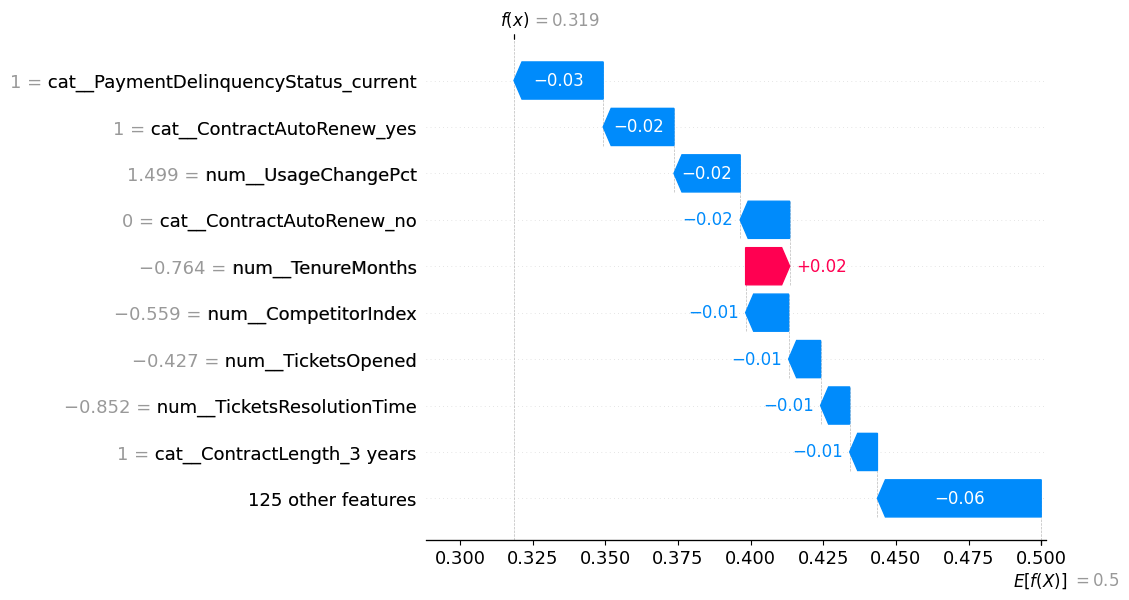

In [ ]:
X_test_for_shap = X_test_enc
if sp.issparse(X_test_for_shap):
    X_test_for_shap = X_test_for_shap.toarray()
X_test_for_shap = X_test_for_shap.astype(float)

idx_test = 0
x_row = X_test_for_shap[idx_test:idx_test+1, :]
x_values_1d = x_row[0]

shap_values_single_raw = explainer.shap_values(x_row)

if isinstance(shap_values_single_raw, list):
    class_idx = 1 if len(shap_values_single_raw) > 1 else 0
    arr = shap_values_single_raw[class_idx][0]
    if arr.ndim == 2 and arr.shape[1] > 1:
        shap_vals_1d = arr[:, 1]
    else:
        shap_vals_1d = arr
    ev = explainer.expected_value[class_idx]
    if np.ndim(ev) > 0:
        expected_val = ev[1] if len(ev) > 1 else ev[0]
    else:
        expected_val = ev
else:
    arr = shap_values_single_raw[0]
    if arr.ndim == 2 and arr.shape[1] > 1:
        shap_vals_1d = arr[:, 1]
    else:
        shap_vals_1d = arr
    ev = explainer.expected_value
    if np.ndim(ev) > 0:
        expected_val = ev[1] if len(ev) > 1 else ev[0]
    else:
        expected_val = ev

exp_local = shap.Explanation(
    values=shap_vals_1d,
    base_values=expected_val,
    data=x_values_1d,
    feature_names=feature_names
)

shap.plots.waterfall(exp_local)


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import scipy.sparse as sp

X_train_dense = X_train_enc.toarray() if sp.issparse(X_train_enc) else X_train_enc
X_test_dense  = X_test_enc.toarray()  if sp.issparse(X_test_enc)  else X_test_enc

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_dense),
    feature_names=feature_names,
    class_names=["No churn", "Churn"],
    mode="classification"
)

i = 0
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_dense[i],
    predict_fn=rf_best.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)


In [ ]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

top_k = 30
top_feature_names = rf_importances.head(top_k).index.tolist()
name_to_idx = {name: i for i, name in enumerate(feature_names)}
loo_features = [f for f in top_feature_names if f in name_to_idx]

print(f"Running LOO on {len(loo_features)} features.")

base_rf = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    **rf_search.best_params_
)
base_rf.fit(X_train_enc, y_train)
base_prob = base_rf.predict_proba(X_test_enc)[:, 1]
base_auc = roc_auc_score(y_test, base_prob)
print("Base RF AUC with all features:", base_auc)

loo_importance = {}
n_features_total = X_train_enc.shape[1]

for feat in loo_features:
    j = name_to_idx[feat]
    keep_mask = np.ones(n_features_total, dtype=bool)
    keep_mask[j] = False

    X_train_loo = X_train_enc[:, keep_mask]
    X_test_loo  = X_test_enc[:, keep_mask]

    rf_clone = clone(base_rf)
    rf_clone.fit(X_train_loo, y_train)
    y_prob_loo = rf_clone.predict_proba(X_test_loo)[:, 1]
    auc_loo = roc_auc_score(y_test, y_prob_loo)

    loo_importance[feat] = base_auc - auc_loo
    print(f"{feat}: AUC drop = {loo_importance[feat]:.4f}")

loo_importance = pd.Series(loo_importance).sort_values(ascending=False)
print("\nTop LOO feature importance:")
print(loo_importance.head(20))


Running LOO on 30 features.
Base RF AUC with all features: 0.7290524948024948
cat__PaymentDelinquencyStatus_current: AUC drop = 0.0015
num__TenureMonths: AUC drop = 0.0150
num__CompetitorIndex: AUC drop = 0.0158
num__MonthlyCharges: AUC drop = 0.0081
num__UsageChangePct: AUC drop = 0.0081
cat__ContractAutoRenew_yes: AUC drop = -0.0043
num__TicketsOpened: AUC drop = 0.0082
cat__PaymentDelinquencyStatus_90+: AUC drop = -0.0021
num__TicketsResolutionTime: AUC drop = 0.0024
num__TotalCharges: AUC drop = -0.0005
cat__PaymentDelinquencyStatus_60+: AUC drop = 0.0004
cat__ContractAutoRenew_no: AUC drop = -0.0008
num__LoginsLastMonth: AUC drop = 0.0008
num__Age: AUC drop = -0.0008
cat__PaymentDelinquencyStatus_120+: AUC drop = 0.0032
cat__PaymentDelinquencyStatus_30+: AUC drop = 0.0032
num__RFMScore: AUC drop = -0.0042
cat__ContractLength_Every month: AUC drop = 0.0025
cat__AutoPay_no: AUC drop = -0.0013
cat__AutoPay_yes: AUC drop = -0.0001
cat__ContractAutoRenew_unknown: AUC drop = -0.0014
cat

In [ ]:
from sklearn.linear_model import LogisticRegression

lasso_selector = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000
)
lasso_selector.fit(X_train_enc, y_train)

coef_mask = np.any(lasso_selector.coef_ != 0, axis=0)
print("Number of features selected by L1:", coef_mask.sum())

X_train_l1 = X_train_enc[:, coef_mask]
X_test_l1  = X_test_enc[:, coef_mask]

selected_l1_feature_names = feature_names[coef_mask]
print("Some L1-selected features:", selected_l1_feature_names[:20])

log_l1_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

log_l1_model = evaluate_model(
    "Logistic Regression (L1-selected)",
    log_l1_model,
    X_train_l1, y_train,
    X_test_l1, y_test,
    results
)


Number of features selected by L1: 108
Some L1-selected features: ['num__Age' 'num__TenureMonths' 'num__MonthlyCharges' 'num__TotalCharges'
 'num__LoginsLastMonth' 'num__TicketsOpened' 'num__TicketsResolutionTime'
 'num__RFMScore' 'num__UsageChangePct' 'num__CompetitorIndex'
 'cat__Gender_Female' 'cat__IncomeTier_high' 'cat__IncomeTier_low'
 'cat__IncomeTier_medium' 'cat__Region_Central' 'cat__Region_East'
 'cat__Region_North' 'cat__Region_South' 'cat__Education_bachelors'
 'cat__Education_high school']

Logistic Regression (L1-selected)
ROC-AUC : 0.7345800415800416
Accuracy: 0.7046
Precision: 0.4508333333333333
Recall: 0.6242307692307693
F1: 0.5235483870967742


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from scipy import sparse

X_train_rfe = X_train_enc.toarray() if sparse.issparse(X_train_enc) else X_train_enc
X_test_rfe  = X_test_enc.toarray()  if sparse.issparse(X_test_enc)  else X_test_enc

base_lr = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000
)

n_features_to_select = 30

rfe = RFE(
    estimator=base_lr,
    n_features_to_select=n_features_to_select,
    step=0.2
)

rfe.fit(X_train_rfe, y_train)
X_train_rfe_sel = rfe.transform(X_train_rfe)
X_test_rfe_sel  = rfe.transform(X_test_rfe)

print("RFE selected", X_train_rfe_sel.shape[1], "features")

rfe_selected_mask = rfe.support_
rfe_selected_feature_names = feature_names[rfe_selected_mask]
print("Some RFE-selected features:", rfe_selected_feature_names[:20])

log_rfe_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

log_rfe_model = evaluate_model(
    f"Logistic Regression (RFE {n_features_to_select})",
    log_rfe_model,
    X_train_rfe_sel, y_train,
    X_test_rfe_sel, y_test,
    results
)


RFE selected 30 features
Some RFE-selected features: ['num__TenureMonths' 'num__MonthlyCharges' 'num__TicketsOpened'
 'num__TicketsResolutionTime' 'num__UsageChangePct' 'num__CompetitorIndex'
 'cat__Gender_Female' 'cat__Gender_Male' 'cat__Education_unknown'
 'cat__ContractLength_Every month' 'cat__DeviceType_unknown'
 'cat__AutoPay_no' 'cat__Paperless_no' 'cat__Paperless_yes'
 'cat__FamilyPlan_yes' 'cat__AddOnBundle_unknown'
 'cat__ReferralSource_billboard' 'cat__ComplaintCategory_outage'
 'cat__ComplaintCategory_unknown' 'cat__DiscountType_employee']

Logistic Regression (RFE 30)
ROC-AUC : 0.7358422557172557
Accuracy: 0.6991
Precision: 0.4442627418915236
Recall: 0.6269230769230769
F1: 0.520019141808901


In [ ]:
from sklearn.feature_selection import SelectFromModel

rf_for_fs = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf_for_fs.fit(X_train_enc, y_train)

selector = SelectFromModel(rf_for_fs, prefit=True, threshold="median")
X_train_sel = selector.transform(X_train_enc)
X_test_sel  = selector.transform(X_test_enc)

selected_mask = selector.get_support()
selected_feature_names = feature_names[selected_mask]
print("Number of selected features:", len(selected_feature_names))
print("Some selected features:", selected_feature_names[:20])

rf_all = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    **rf_search.best_params_
)
rf_all.fit(X_train_enc, y_train)
auc_all = roc_auc_score(y_test, rf_all.predict_proba(X_test_enc)[:, 1])

rf_sel_model = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    **rf_search.best_params_
)
rf_sel_model.fit(X_train_sel, y_train)
auc_sel = roc_auc_score(y_test, rf_sel_model.predict_proba(X_test_sel)[:, 1])

print("RF AUC with ALL features:     ", auc_all)
print("RF AUC with SELECTED features:", auc_sel)


Number of selected features: 67
Some selected features: ['num__Age' 'num__TenureMonths' 'num__MonthlyCharges' 'num__TotalCharges'
 'num__LoginsLastMonth' 'num__TicketsOpened' 'num__TicketsResolutionTime'
 'num__RFMScore' 'num__UsageChangePct' 'num__CompetitorIndex'
 'cat__Gender_Female' 'cat__Gender_Male' 'cat__IncomeTier_high'
 'cat__IncomeTier_low' 'cat__IncomeTier_very high' 'cat__Region_Central'
 'cat__Region_East' 'cat__Region_North' 'cat__Region_South'
 'cat__Region_West']
RF AUC with ALL features:      0.7290524948024948
RF AUC with SELECTED features: 0.7298953222453222


In [ ]:

comparison = pd.DataFrame({
    model: {metric: val for metric, val in res.items() if metric != "model"}
    for model, res in results.items()
}).T

if "cv_scores" in globals():
    for name, scores in cv_scores.items():
        if name in comparison.index:
            comparison.loc[name, "CV_Mean_AUC"] = scores["cv_mean_auc"]
            comparison.loc[name, "CV_Std_AUC"]  = scores["cv_std_auc"]

comparison_sorted = comparison.sort_values(by="ROC_AUC", ascending=False)
comparison_sorted


,ROC_AUC,Accuracy,Precision,Recall,F1,CV_Mean_AUC,CV_Std_AUC
XGBoost (Optuna),0.737331,0.8311,0.867635,0.413462,0.560042,NaN,NaN
Gradient Boosting,0.737290,0.8301,0.861847,0.412692,0.558127,0.733266,0.005451
ANN / MLP,0.736147,0.8362,0.864947,0.438462,0.581930,0.736144,0.003850
SVM (Linear + Calibrated),0.736048,0.8227,0.845447,0.389231,0.533052,0.729883,0.004475
Logistic Regression (RFE 30),0.735842,0.6991,0.444263,0.626923,0.520019,NaN,NaN
XGBoost,0.735251,0.8322,0.862992,0.421538,0.566408,0.732445,0.005482
Logistic Regression,0.734911,0.7028,0.448619,0.624615,0.522186,0.729145,0.004325
Logistic Regression (L1-selected),0.734580,0.7046,0.450833,0.624231,0.523548,NaN,NaN
Random Forest,0.729052,0.8027,0.666313,0.483077,0.560089,0.723147,0.005651
Decision Tree,0.705475,0.7634,0.552093,0.476923,0.511762,0.702753,0.002741


In [ ]:
accuracy_table = pd.DataFrame({
    model: res["Accuracy"]
    for model, res in results.items()
}, index=["Accuracy"]).T

accuracy_sorted = accuracy_table.sort_values(by="Accuracy", ascending=False)
accuracy_sorted


,Accuracy
ANN / MLP,0.8362
XGBoost,0.8322
XGBoost (Optuna),0.8311
Gradient Boosting,0.8301
SVM (Linear + Calibrated),0.8227
Random Forest,0.8027
Decision Tree,0.7634
Logistic Regression (L1-selected),0.7046
Logistic Regression,0.7028
Logistic Regression (RFE 30),0.6991


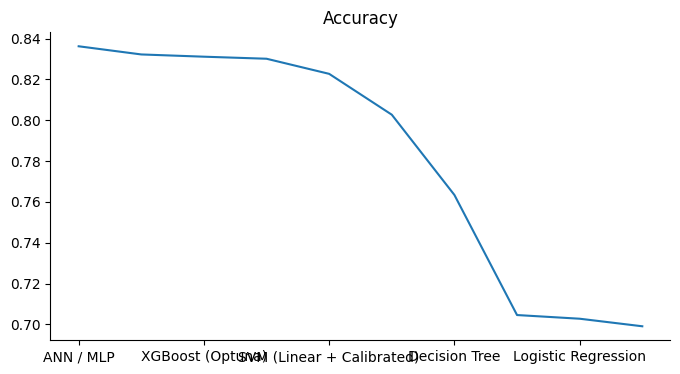

In [ ]:
from matplotlib import pyplot as plt
accuracy_sorted['Accuracy'].plot(kind='line', figsize=(8, 4), title='Accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)